# Waste Sorting Classification with TrashNet

This notebook builds a recyclable-waste classifier on the real TrashNet download using PyTorch, timm, and Albumentations.

## Project Overview
This notebook trains a compact image classifier to separate cardboard, glass, metal, paper, plastic, and trash.

## Learning Objectives
- Download and validate the real TrashNet dataset inside the notebook.
- Fine-tune a timm backbone with Albumentations augmentations.
- Explain and inspect practical dataset noise.

## Problem Statement
Waste images contain confusing materials, contamination, and lighting variation. A model that helps sorting has to handle ambiguity, not just clean studio images.

## Why This Project Matters
Automated waste sorting can reduce manual burden, but only if the model is evaluated honestly on noisy examples.

## Dataset Overview
TrashNet is a small six-class waste image dataset often used for educational recycling projects.

## Dataset Source and License Notes
Dataset source link: https://github.com/garythung/trashnet

The notebook downloads the dataset directly from the public source repository during execution. Review the source repository for current license terms before redistributing derived assets.

### Practical Dataset Noise
- Some objects are mixed-material items, so labels are imperfect simplifications.
- Dirty paper, crushed plastic, and reflective metal often look like other classes.
- Recyclability policies differ across locations, so category labels are not universal disposal instructions.
- Background clutter and camera angle can become shortcuts for the model.

## Environment Setup
The notebook installs missing dependencies in the active environment instead of assuming they already exist.

In [1]:
import importlib
import subprocess
import sys

required_packages = {
    'albumentations': 'albumentations',
    'nbformat': 'nbformat',
    'scikit-learn': 'sklearn',
    'seaborn': 'seaborn',
    'timm': 'timm',
}

for package_name, import_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

print('Environment setup complete.')

E:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment setup complete.


## Imports
These imports cover data access, augmentation, training, and evaluation.

In [2]:
import json
import math
import random
import shutil
import urllib.request
import zipfile
from pathlib import Path

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
import timm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

## Configuration / Constants
Keep runtime choices explicit so the notebook is reproducible and easy to adapt.

In [3]:
SEED = 42
IMAGE_SIZE = 160
BATCH_SIZE = 32
NUM_EPOCHS = 1 if not torch.cuda.is_available() else 3
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = 'resnet18'
DATASET_URL = 'https://github.com/garythung/trashnet/archive/refs/heads/master.zip'
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
ARCHIVE_PATH = DATA_DIR / 'trashnet.zip'
EXTRACT_DIR = DATA_DIR / 'trashnet_extracted'
METRICS_PATH = PROJECT_DIR / 'metrics.json'

DATA_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'device': str(DEVICE), 'epochs': NUM_EPOCHS, 'project_dir': str(PROJECT_DIR)})

{'device': 'cuda', 'epochs': 3, 'project_dir': 'E:\\Github\\Machine-Learning-Projects\\Computer Vision\\Waste Sorting Classification'}


## Dataset Download and Loading
The dataset is downloaded and extracted inside the notebook. There is no synthetic fallback.

In [4]:
if not ARCHIVE_PATH.exists():
    print(f'Downloading TrashNet from {DATASET_URL}')
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)

candidate_paths = [
    EXTRACT_DIR / 'trashnet-master' / 'data' / 'dataset-resized',
    EXTRACT_DIR / 'trashnet-master' / 'data' / 'dataset-resized.zip',
    EXTRACT_DIR / 'trashnet-main' / 'data' / 'dataset-resized',
    EXTRACT_DIR / 'trashnet-main' / 'data' / 'dataset-resized.zip',
]
dataset_dir = None
dataset_zip_path = None

for candidate in candidate_paths:
    if candidate.exists() and candidate.is_dir():
        dataset_dir = candidate
        break
    if candidate.exists() and candidate.suffix == '.zip':
        dataset_zip_path = candidate

if dataset_dir is None and dataset_zip_path is None:
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_DIR)
    for candidate in candidate_paths:
        if candidate.exists() and candidate.is_dir():
            dataset_dir = candidate
            break
        if candidate.exists() and candidate.suffix == '.zip':
            dataset_zip_path = candidate

if dataset_dir is None and dataset_zip_path is not None:
    extracted_dataset_dir = dataset_zip_path.with_suffix('')
    if not extracted_dataset_dir.exists():
        with zipfile.ZipFile(dataset_zip_path, 'r') as zip_file:
            zip_file.extractall(dataset_zip_path.parent)
    if extracted_dataset_dir.exists():
        dataset_dir = extracted_dataset_dir

if dataset_dir is None:
    raise RuntimeError('Downloaded TrashNet archive, but dataset-resized was not found after extraction.')

class_names = sorted([path.name for path in dataset_dir.iterdir() if path.is_dir()])
print({'dataset_dir': str(dataset_dir), 'classes': class_names})

{'dataset_dir': 'E:\\Github\\Machine-Learning-Projects\\Computer Vision\\Waste Sorting Classification\\data\\trashnet_extracted\\trashnet-master\\data\\dataset-resized', 'classes': ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']}


## Data Validation Checks
Validate that the downloaded dataset contains real, readable image files before training.

In [5]:
records = []
for class_name in class_names:
    class_dir = dataset_dir / class_name
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
            records.append({'path': image_path, 'label_name': class_name})

data = pd.DataFrame(records)
if data.empty:
    raise RuntimeError('No images were found in the downloaded dataset.')

label_map = {name: index for index, name in enumerate(class_names)}
data['label'] = data['label_name'].map(label_map)
data['relative_path'] = data['path'].map(lambda path: path.relative_to(dataset_dir).as_posix())
duplicates = int(data['relative_path'].duplicated().sum())
corrupt_files = []

for image_path in data['path']:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception:
        corrupt_files.append(str(image_path))

if duplicates != 0 or corrupt_files:
    raise RuntimeError({'duplicates': duplicates, 'corrupt_files': corrupt_files[:5]})

class_counts = data['label_name'].value_counts().sort_index()
print({'num_images': len(data), 'class_counts': class_counts.to_dict()})

{'num_images': 2527, 'class_counts': {'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}}


## Exploratory Data Analysis
Class balance and example images reveal where the dataset is clean and where it is visually messy.

## Train/Validation/Test Split Strategy
This notebook creates a stratified 70/15/15 split because TrashNet does not ship with a fixed benchmark split.

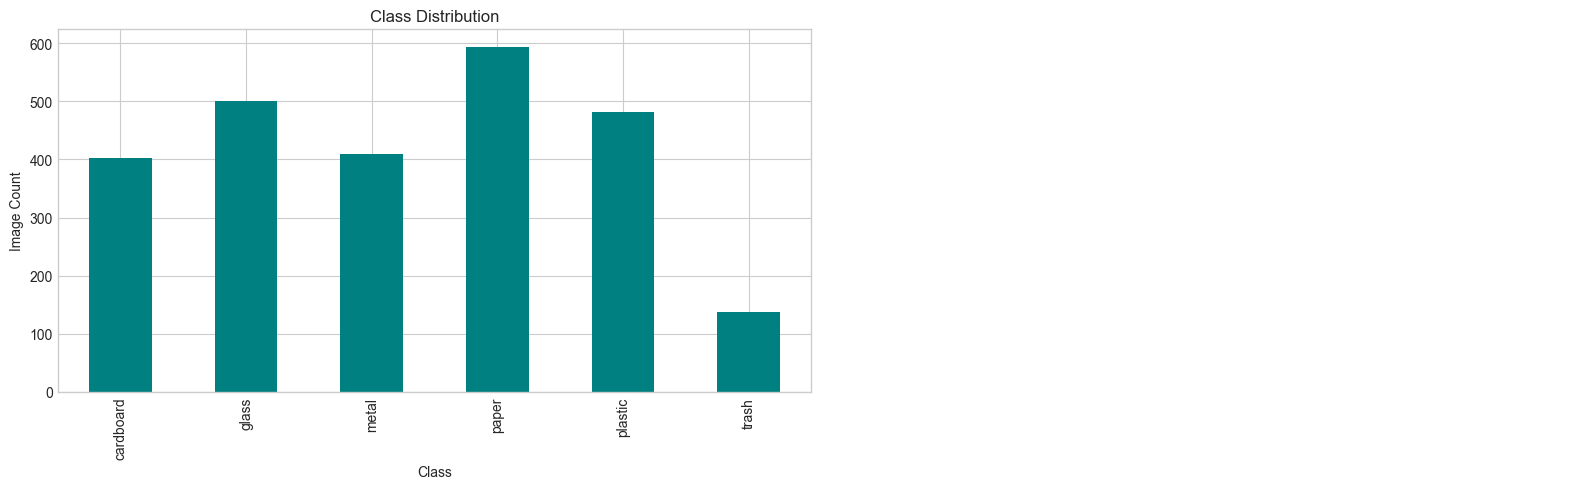

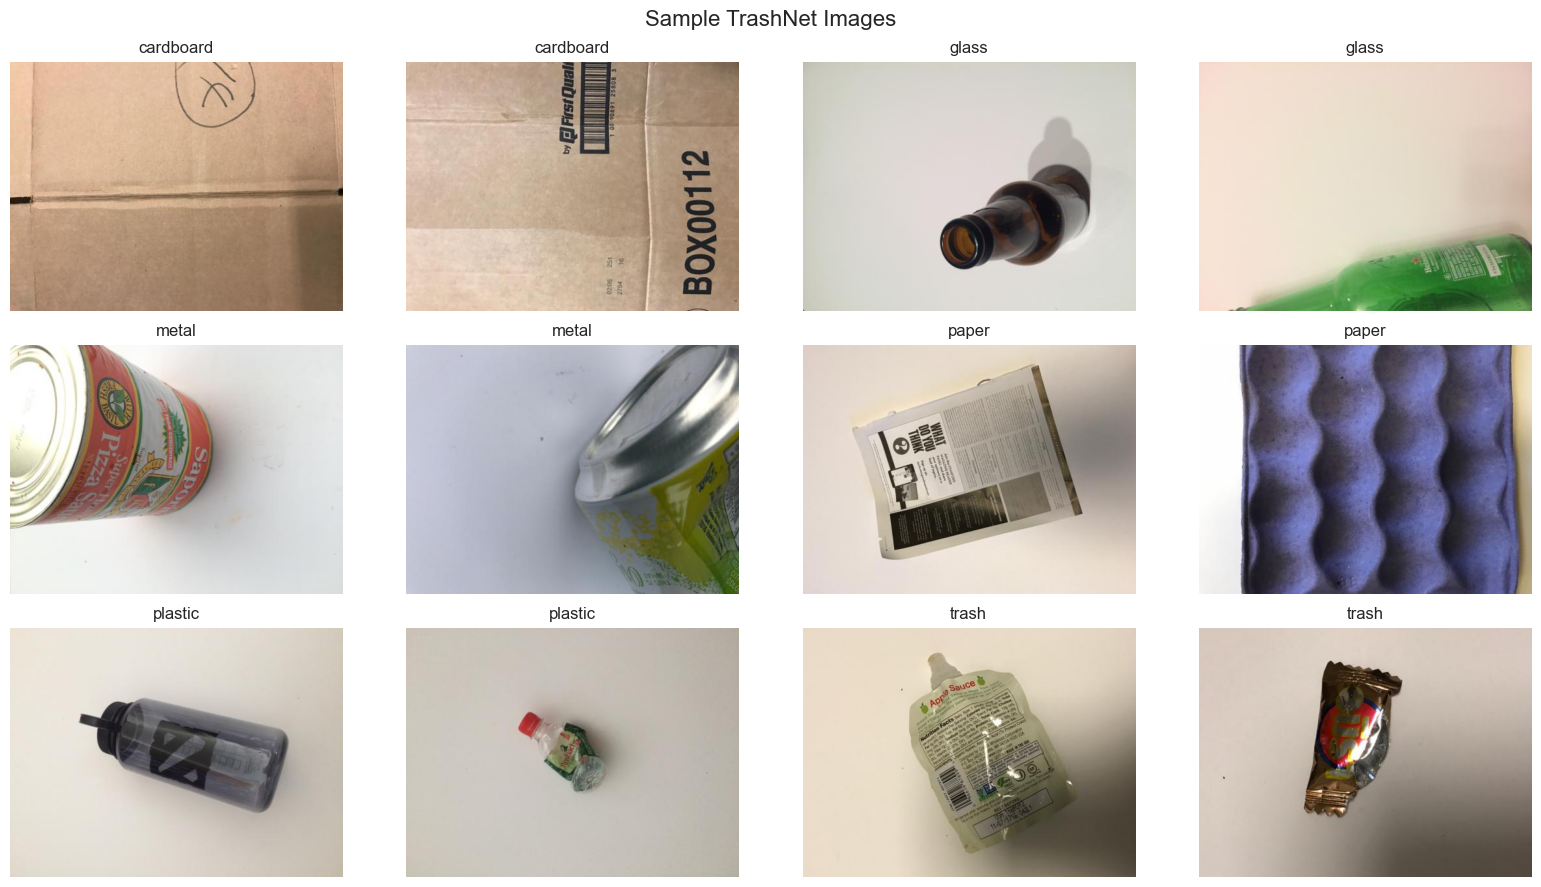

train 1768 {'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 416, 'plastic': 337, 'trash': 96}
val 379 {'cardboard': 61, 'glass': 75, 'metal': 61, 'paper': 89, 'plastic': 72, 'trash': 21}
test 380 {'cardboard': 60, 'glass': 76, 'metal': 62, 'paper': 89, 'plastic': 73, 'trash': 20}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
class_counts.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
axes[1].axis('off')
fig.tight_layout()
plt.show()

sample_rows = data.groupby('label_name', group_keys=False).head(2).reset_index(drop=True)
rows = math.ceil(len(sample_rows) / 4)
figure, sample_axes = plt.subplots(rows, 4, figsize=(16, 3 * rows))
sample_axes = np.array(sample_axes).reshape(rows, 4)
for axis in sample_axes.ravel():
    axis.axis('off')
for index, row in sample_rows.iterrows():
    axis = sample_axes.ravel()[index]
    axis.imshow(Image.open(row['path']).convert('RGB'))
    axis.set_title(row['label_name'])
    axis.axis('off')
figure.suptitle('Sample TrashNet Images', fontsize=16)
figure.tight_layout()
plt.show()

train_frame, temp_frame = train_test_split(data, test_size=0.30, random_state=SEED, stratify=data['label'])
val_frame, test_frame = train_test_split(temp_frame, test_size=0.50, random_state=SEED, stratify=temp_frame['label'])
for split_name, frame in [('train', train_frame), ('val', val_frame), ('test', test_frame)]:
    print(split_name, len(frame), frame['label_name'].value_counts().sort_index().to_dict())

## Preprocessing and Augmentation Strategy
Albumentations provides moderate flips, affine transforms, and color jitter so the model learns beyond one exact pose or lighting condition.

## Baseline Approach
A majority-class baseline shows how a naive classifier performs if it always predicts the most common class.

## Main Model / Workflow
The main model is a timm `resnet18` fine-tuned on TrashNet.

In [7]:
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-12, 12), p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
eval_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class TrashNetDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row['path']).convert('RGB')
        image = np.array(image)
        tensor = self.transform(image=image)['image']
        return tensor, int(row['label'])

train_dataset = TrashNetDataset(train_frame, train_transform)
val_dataset = TrashNetDataset(val_frame, eval_transform)
test_dataset = TrashNetDataset(test_frame, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=DEVICE.type == 'cuda')
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type == 'cuda')

majority_class = int(train_frame['label'].mode().iloc[0])
baseline_predictions = np.full(shape=len(test_frame), fill_value=majority_class)
baseline_accuracy = accuracy_score(test_frame['label'], baseline_predictions)
baseline_macro_f1 = f1_score(test_frame['label'], baseline_predictions, average='macro')

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(class_names)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print({'baseline_accuracy': baseline_accuracy, 'baseline_macro_f1': baseline_macro_f1})

{'baseline_accuracy': 0.23421052631578948, 'baseline_macro_f1': 0.06325515280739162}


## Training Loop or Fine-Tuning Pipeline
A short real run is enough to validate the full workflow while keeping execution practical on CPU.

In [8]:
def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_examples = 0
    all_targets = []
    all_predictions = []
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits, targets)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        predictions = logits.argmax(dim=1)
        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        all_targets.extend(targets.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())
    return total_loss / total_examples, accuracy_score(all_targets, all_predictions)

history = []
best_state = None
best_val_accuracy = -1.0
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    with torch.no_grad():
        val_loss, val_accuracy = run_epoch(val_loader, training=False)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'val_loss': val_loss, 'val_accuracy': val_accuracy})
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    print(history[-1])

if best_state is None:
    raise RuntimeError('Training did not produce a valid checkpoint.')

model.load_state_dict(best_state)
history_frame = pd.DataFrame(history)
history_frame

{'epoch': 1, 'train_loss': 1.5130517585245193, 'train_accuracy': 0.458710407239819, 'val_loss': 1.1822902196944547, 'val_accuracy': 0.6781002638522428}


{'epoch': 2, 'train_loss': 0.9289697619045482, 'train_accuracy': 0.7047511312217195, 'val_loss': 0.7248993739289156, 'val_accuracy': 0.7546174142480211}


{'epoch': 3, 'train_loss': 0.590345888116241, 'train_accuracy': 0.8014705882352942, 'val_loss': 0.5200837161735997, 'val_accuracy': 0.820580474934037}


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.513052,0.458710,1.182290,0.678100
1,2,0.928970,0.704751,0.724899,0.754617
2,3,0.590346,0.801471,0.520084,0.820580


## Inference Examples
Inference examples show model behavior on held-out images.

## Evaluation
Accuracy, balanced accuracy, macro F1, and the confusion matrix provide a more honest view than raw accuracy alone.

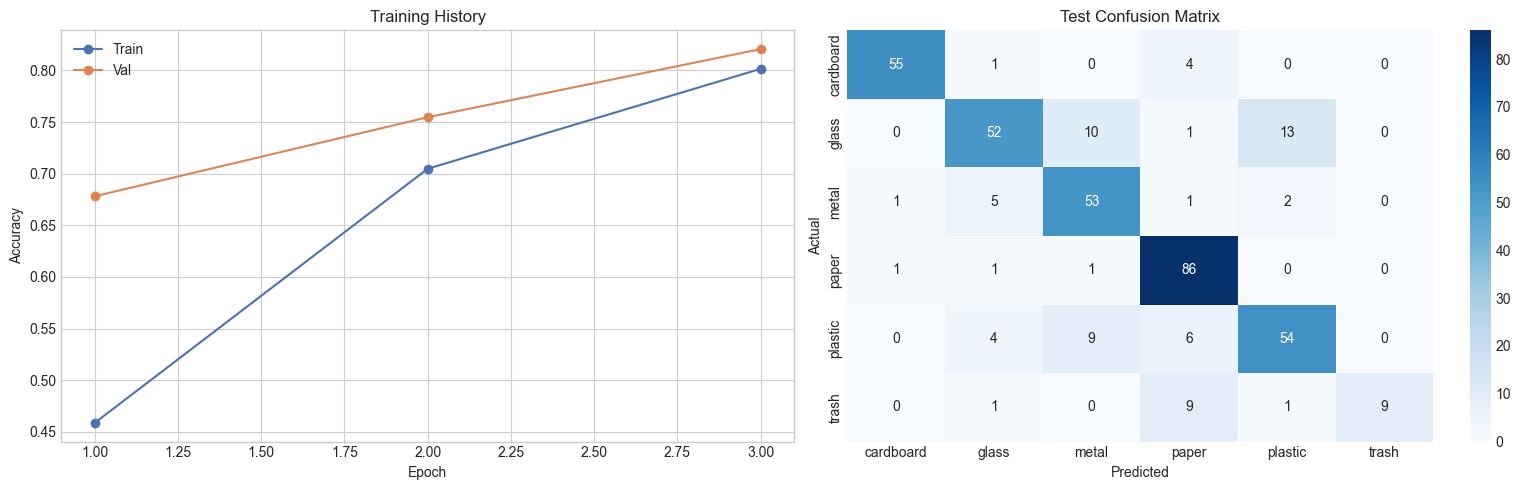

,precision,recall,f1-score,support
cardboard,0.965,0.917,0.940,60.000
glass,0.812,0.684,0.743,76.000
metal,0.726,0.855,0.785,62.000
paper,0.804,0.966,0.878,89.000
plastic,0.771,0.740,0.755,73.000
trash,1.000,0.450,0.621,20.000
accuracy,0.813,0.813,0.813,0.813
macro avg,0.846,0.769,0.787,380.000
weighted avg,0.822,0.813,0.808,380.000


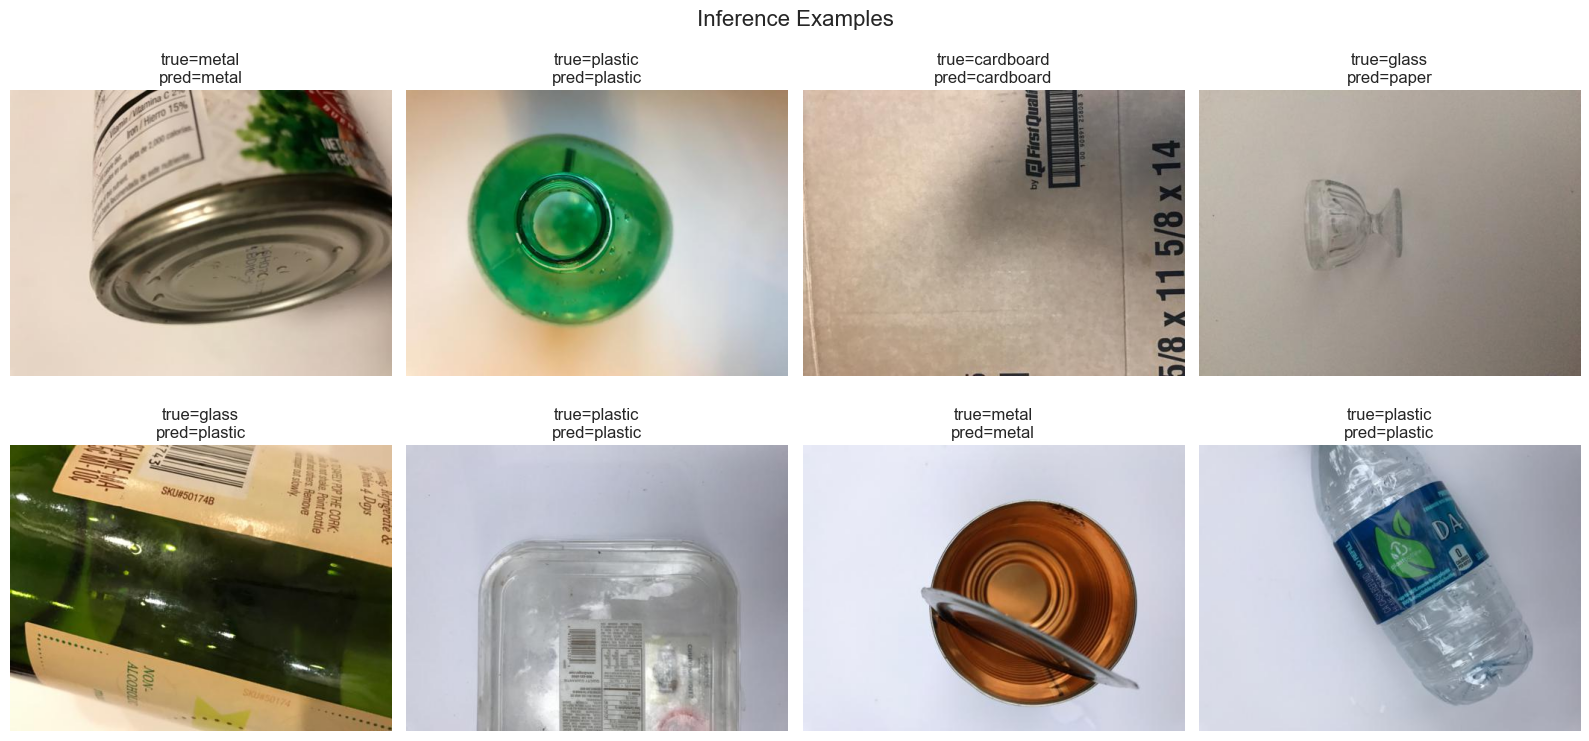

{'baseline_accuracy': 0.2342, 'test_accuracy': 0.8132, 'test_macro_f1': 0.7869, 'metrics_path': 'E:\\Github\\Machine-Learning-Projects\\Computer Vision\\Waste Sorting Classification\\metrics.json'}


In [9]:
@torch.no_grad()
def predict_dataset(loader):
    model.eval()
    all_targets = []
    all_predictions = []
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE)
        logits = model(inputs)
        predictions = logits.argmax(dim=1)
        all_targets.extend(targets.numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())
    return np.array(all_targets), np.array(all_predictions)

y_true, y_pred = predict_dataset(test_loader)
test_accuracy = accuracy_score(y_true, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average='macro')
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
conf_matrix = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history_frame['epoch'], history_frame['train_accuracy'], marker='o', label='Train')
axes[0].plot(history_frame['epoch'], history_frame['val_accuracy'], marker='o', label='Val')
axes[0].set_title('Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
fig.tight_layout()
plt.show()

display(pd.DataFrame(report).transpose().round(3))

inference_rows = test_frame.reset_index(drop=True).head(8)
figure, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis in axes.ravel():
    axis.axis('off')
for index, row in inference_rows.iterrows():
    image = Image.open(row['path']).convert('RGB')
    tensor = eval_transform(image=np.array(image))['image'].unsqueeze(0).to(DEVICE)
    prediction = int(model(tensor).argmax(dim=1).item())
    axis = axes.ravel()[index]
    axis.imshow(image)
    axis.set_title(f"true={row['label_name']}\npred={class_names[prediction]}")
    axis.axis('off')
figure.suptitle('Inference Examples', fontsize=16)
figure.tight_layout()
plt.show()

metrics = {
    'dataset': 'TrashNet',
    'dataset_source': 'https://github.com/garythung/trashnet',
    'model_name': MODEL_NAME,
    'device': str(DEVICE),
    'num_epochs': NUM_EPOCHS,
    'class_names': class_names,
    'train_size': int(len(train_frame)),
    'val_size': int(len(val_frame)),
    'test_size': int(len(test_frame)),
    'baseline_accuracy': float(baseline_accuracy),
    'baseline_macro_f1': float(baseline_macro_f1),
    'test_accuracy': float(test_accuracy),
    'test_balanced_accuracy': float(test_balanced_accuracy),
    'test_macro_f1': float(test_macro_f1),
    'classification_report': report,
    'dataset_noise_note': 'TrashNet contains ambiguity from mixed materials, contamination, background clutter, and visually overlapping classes.',
}
with open(METRICS_PATH, 'w', encoding='utf-8') as file:
    json.dump(metrics, file, indent=2)
print({'baseline_accuracy': round(baseline_accuracy, 4), 'test_accuracy': round(test_accuracy, 4), 'test_macro_f1': round(test_macro_f1, 4), 'metrics_path': str(METRICS_PATH)})

## Error Analysis
Inspecting concrete mistakes is the fastest way to connect metric drops to practical dataset noise.

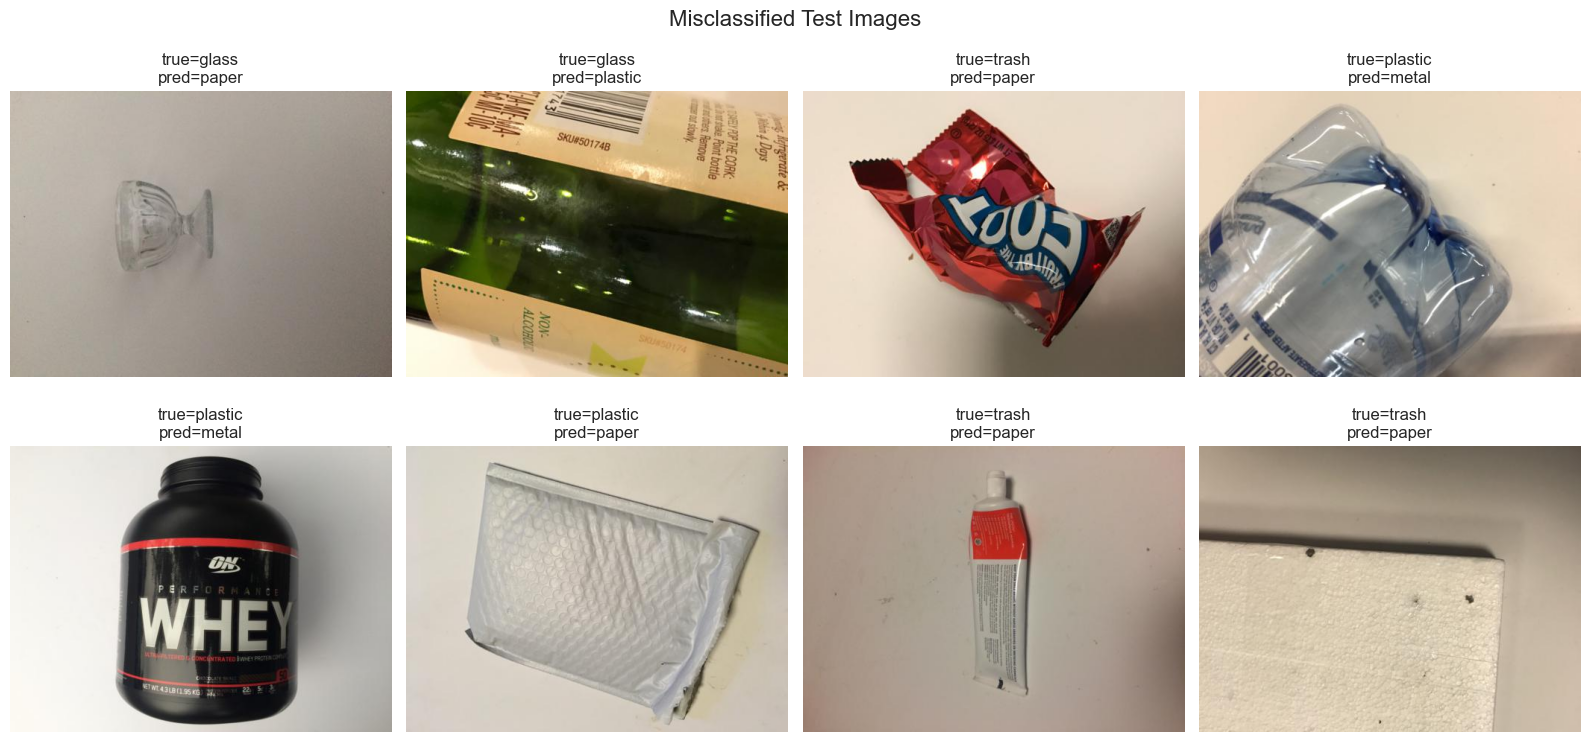

,relative_path,true_name,pred_name
0,glass/glass183.jpg,glass,paper
1,glass/glass401.jpg,glass,plastic
2,trash/trash66.jpg,trash,paper
3,plastic/plastic123.jpg,plastic,metal
4,plastic/plastic199.jpg,plastic,metal
5,plastic/plastic455.jpg,plastic,paper
6,trash/trash130.jpg,trash,paper
7,trash/trash92.jpg,trash,paper


In [10]:
error_frame = test_frame.reset_index(drop=True).copy()
error_frame['true_name'] = [class_names[index] for index in y_true]
error_frame['pred_name'] = [class_names[index] for index in y_pred]
mistakes = error_frame[error_frame['true_name'] != error_frame['pred_name']].head(8).reset_index(drop=True)
if mistakes.empty:
    print('No misclassifications were found in the current test predictions.')
else:
    figure, axes = plt.subplots(2, 4, figsize=(16, 8))
    for axis in axes.ravel():
        axis.axis('off')
    for index, row in mistakes.iterrows():
        axis = axes.ravel()[index]
        axis.imshow(Image.open(row['path']).convert('RGB'))
        axis.set_title(f"true={row['true_name']}\npred={row['pred_name']}")
        axis.axis('off')
    figure.suptitle('Misclassified Test Images', fontsize=16)
    figure.tight_layout()
    plt.show()
mistakes[['relative_path', 'true_name', 'pred_name']].head(10)

## Limitations
- TrashNet is small and sensitive to split variation.
- Material category is not the same thing as recycling policy.
- Label ambiguity is part of the dataset, not just a modeling issue.

## How to Improve This Project
- Use a stronger timm backbone and a longer schedule on GPU.
- Add confidence thresholds and manual-review routing.
- Collect more local images from the real waste stream you care about.

## Production Considerations
- Expect domain shift from curated photos to conveyor or bin-line images.
- Combine image predictions with rule-based recycling guidance.
- Log uncertain cases for retraining.

## Common Mistakes
- Treating dataset labels as universal disposal advice.
- Reporting accuracy alone and ignoring minority-class behavior.
- Hiding ambiguous examples instead of documenting practical dataset noise.

## Mini Challenge / Exercises
1. Swap `resnet18` for a stronger timm backbone and compare macro F1.
2. Add label smoothing and inspect minority-class recall.
3. Add a low-confidence abstain class for safer human review.

## Final Summary / Key Takeaways
This notebook runs on the real TrashNet download, trains a timm classifier, exports metrics, and shows that practical dataset noise is central to waste-sorting performance, not an edge case.